In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo

Project         : Visualization of Optimization Algorithms
Algorithm       : Adam (Adaptive Moment Estimation)

Description     : Visualizes the Adam optimizer. Adam combines the benefits 
                  of Momentum (first moment) and RMSprop (second moment) 
                  and is one of the most widely used optimizers in deep learning.
============================================================================
"""

import numpy as np
from matplotlib import pyplot as plt

In [5]:
# cost= lambda w: w**4
# grad= lambda w:4*w**3

cost= lambda w: 0.3*w**4-0.1*w**3-2*w**2-0.8*w
grad= lambda w:1.2*w**3- 0.3*w**2- 4*w-0.8

In [6]:
w0=np.array([-2.8])
j0= cost(w0)

SGD 

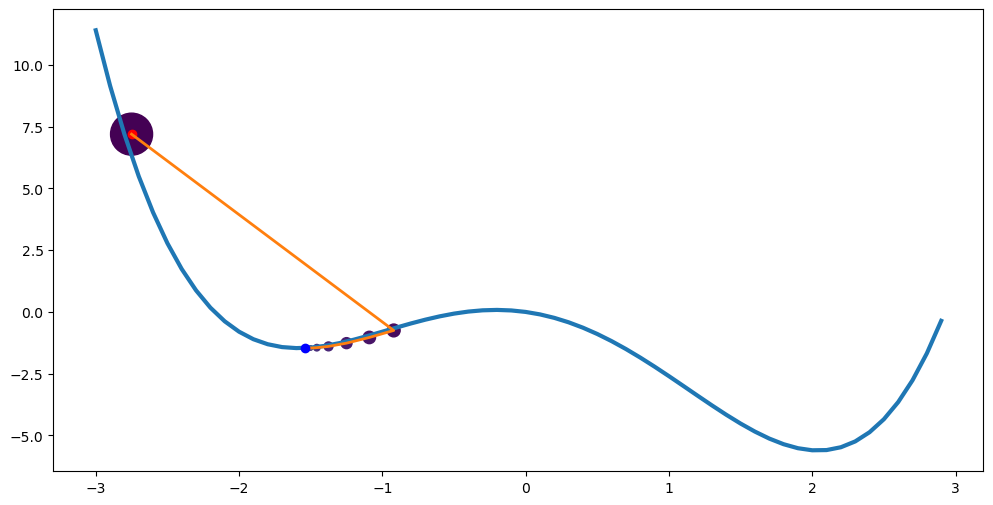

In [7]:

lr=0.1
w=w0
epoch=40

wn=[]
jn=[]
gn=[]
for iter in range(1,epoch+1):
     wn.append(w)
     jn.append(cost(w))
     
     g= grad(w)
     w= w-lr*g
     
     gn.append(g)


wn= np.array(wn)
jn= np.array(jn)
gn= np.array(gn)

x=np.arange(-3,3,0.1)
y= cost(x)
plt.figure(figsize=(12, 6))
plt.plot(x,y,linewidth=3)
plt.plot(w0+0.05,j0,'ro')
plt.plot(wn+0.05,jn,'-',linewidth=2)
color= np.arange(wn.size)
plt.scatter(wn+0.05,jn,s=np.abs(gn)*50,c=color)
plt.plot(wn[-1]+0.05,jn[-1],'bo')
plt.show()

Adam (Adaptive momentum estimation)

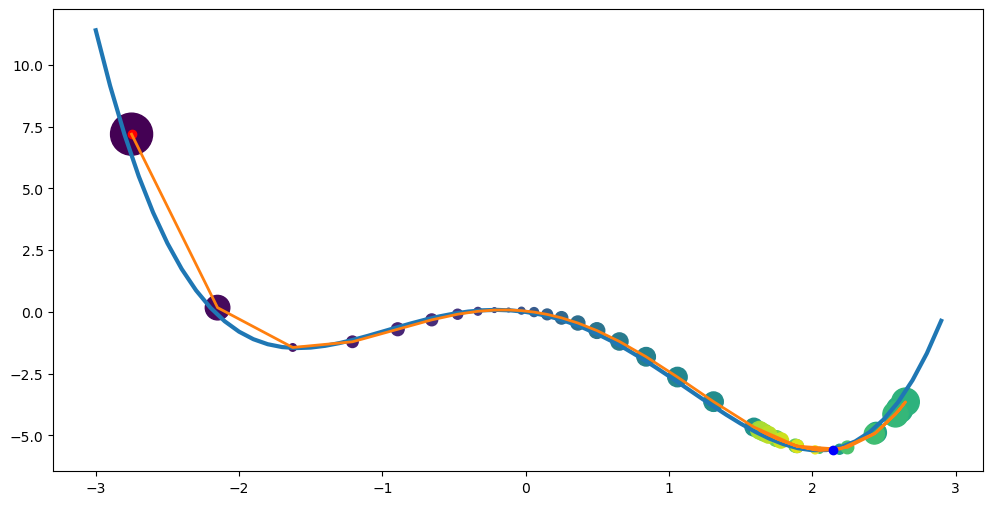

In [8]:
lr=0.6
beta1=0.9
beta2=0.999
vt=0
mt=0
eps= 10e-8
w1=w0
wn1=[]
jn1=[]
gn1=[]
for t in range(1,epoch+1):
     wn1.append(w1)
     jn1.append(cost(w1))
     
     gt= grad(w1)
     vt= beta1*vt+ (1-beta1)*gt
     mt= beta2*mt+ (1-beta2)*gt*gt
     
     vt_hat= vt/(1-beta1**t)
     mt_hat= mt/(1-beta2**t)
     
     RMS_mt_hat= np.sqrt(eps+mt_hat)
     dw= -lr*(vt_hat/RMS_mt_hat)
     w1= w1 + dw
     
     gn1.append(gt)

wn1= np.array(wn1)
jn1= np.array(jn1)
gn1= np.array(gn1)

x=np.arange(-3,3,0.1)
y= cost(x)
plt.figure(figsize=(12, 6))
plt.plot(x,y,linewidth=3)
plt.plot(w0+0.05,j0,'ro')
plt.plot(wn1+0.05,jn1,'-',linewidth=2)
color= np.arange(wn1.size)
plt.scatter(wn1+0.05,jn1,s=np.abs(gn1)*50,c=color)
plt.plot(wn1[-1]+0.05,jn1[-1],'bo')
plt.show()

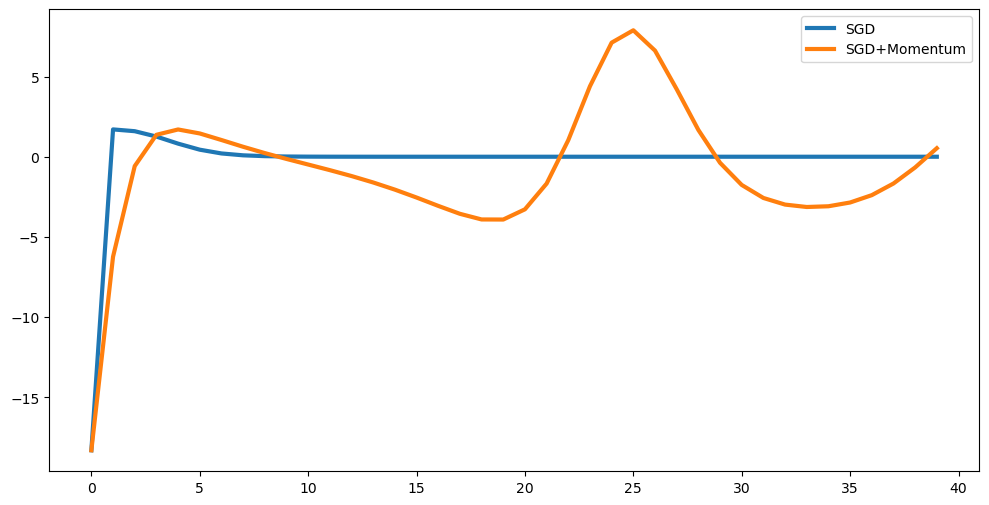

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(gn,label='SGD',linewidth=3)
plt.plot(gn1,label='SGD+Momentum',linewidth=3)
plt.legend()
plt.show()